# AI Crypto Hedge Fund MVP

This notebook is the final technical solution for the AI Crypto Hedge Fund assignment. It uses repository modules and committed report artifacts rather than duplicating implementation logic inline.

The notebook is designed to run without network calls. By default it reads committed sample data and committed report artifacts. The authoritative metrics shown in the report artifacts were generated on `beleriand` from the ignored full 1-minute Binance spot bundle documented in `data/manifest.json`.

## 0. Setup, Data Mode, and Helpers

Set `DATA_MODE=sample` for a lightweight smoke run from committed data only. Set `DATA_MODE=full` after preparing or downloading `data/external/binance_spot_1m_120_12mo/`; the notebook still reads committed report artifacts so it stays fast enough for review.

In [1]:
import json
import os
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

from ai_crypto_hedge_fund import project_root
from ai_crypto_hedge_fund.data.loaders import load_price_matrix, snapshot_processed_dir

ROOT = project_root()
DATA_MODE = os.environ.get("DATA_MODE", "sample")
if DATA_MODE not in {"sample", "full"}:
    raise ValueError("DATA_MODE must be 'sample' or 'full'.")

REPORTS = ROOT / "reports"
METRICS = REPORTS / "metrics"
FIGURES = REPORTS / "figures"


def load_json(relative_path: str) -> dict:
    return json.loads((ROOT / relative_path).read_text())


def comparison_frame(payload: dict) -> pd.DataFrame:
    frame = pd.DataFrame(payload["comparison_table"])
    numeric = frame.select_dtypes(include="number").columns
    frame[numeric] = frame[numeric].round(4)
    return frame


def show_figure(relative_path: str, width: int = 900) -> None:
    path = ROOT / relative_path
    if path.exists():
        display(Image(filename=str(path), width=width))
    else:
        display(Markdown(f"Missing figure: `{relative_path}`"))

{"project_root": ROOT.name, "data_mode": DATA_MODE}

{'project_root': 'AI-Crypto-Hedge-Fund-CMF', 'data_mode': 'sample'}

## 1. Data Preparation and Universe Summary

Market data comes from public Binance spot data. The repository includes a compact 1-minute sample for offline smoke runs. The full 120-pair bundle is intentionally ignored by git and documented with checksums for final packaging.

In [2]:
manifest = load_json("data/manifest.json")
prices = load_price_matrix(snapshot=DATA_MODE)

summary = {
    "data_mode": DATA_MODE,
    "price_rows": len(prices),
    "price_columns": prices.shape[1],
    "first_timestamp": str(prices.index.min()),
    "last_timestamp": str(prices.index.max()),
    "sample_symbols": list(prices.columns[:10]),
    "full_snapshot_symbol_count": manifest["snapshots"]["full"]["symbol_count"],
    "full_processed_bundle": {
        "relative_dir": manifest["snapshots"]["full"].get("processed_bundle", {}).get("relative_dir"),
        "publication_status": manifest["snapshots"]["full"].get("processed_bundle", {}).get("publication_status"),
        "files": manifest["snapshots"]["full"].get("processed_bundle", {}).get("files", {}),
    },
}
summary

{'data_mode': 'sample',
 'price_rows': 10080,
 'price_columns': 6,
 'first_timestamp': '2026-06-01 00:00:00+00:00',
 'last_timestamp': '2026-06-07 23:59:00+00:00',
 'sample_symbols': ['BTCUSDT',
  'ETHUSDT',
  'BNBUSDT',
  'SOLUSDT',
  'XRPUSDT',
  'ADAUSDT'],
 'full_snapshot_symbol_count': 120,
 'full_processed_bundle': {'relative_dir': 'data/external/binance_spot_1m_120_12mo/processed',
  'publication_status': 'deferred_to_task_13',
  'files': {'prices_1m.parquet': {'size_bytes': 95258376,
    'sha256': '027a8a0ba6841e04e39513f8262a5d451bcb27369bb07a308e6059d617ef9dff'},
   'returns_1m.parquet': {'size_bytes': 193142203,
    'sha256': '2c4b8ed154f959fe7cb598524b214fcb423acab61ef3ae3169a4c717af6fe491'}}}}

## 2.1 Baseline Strategy for a Single Cryptocurrency

The baseline uses BTCUSDT and compares buy-and-hold with a transparent dual moving-average crossover strategy. Signals are shifted by one period before execution and transaction costs are charged from turnover.

In [3]:
baseline_metrics = load_json("reports/metrics/baseline_metrics.json")
comparison_frame({
    "comparison_table": [
        {"strategy": name, **metrics}
        for name, metrics in baseline_metrics["strategies"].items()
    ]
})[["strategy", "total_return", "annualized_volatility", "sharpe_ratio", "max_drawdown", "turnover"]]

,strategy,total_return,annualized_volatility,sharpe_ratio,max_drawdown,turnover
0,buy_and_hold,-0.1126,0.4310,-0.7224,-0.2859,1.0
1,moving_average_crossover,-0.4040,0.2942,-5.8061,-0.4091,657.0


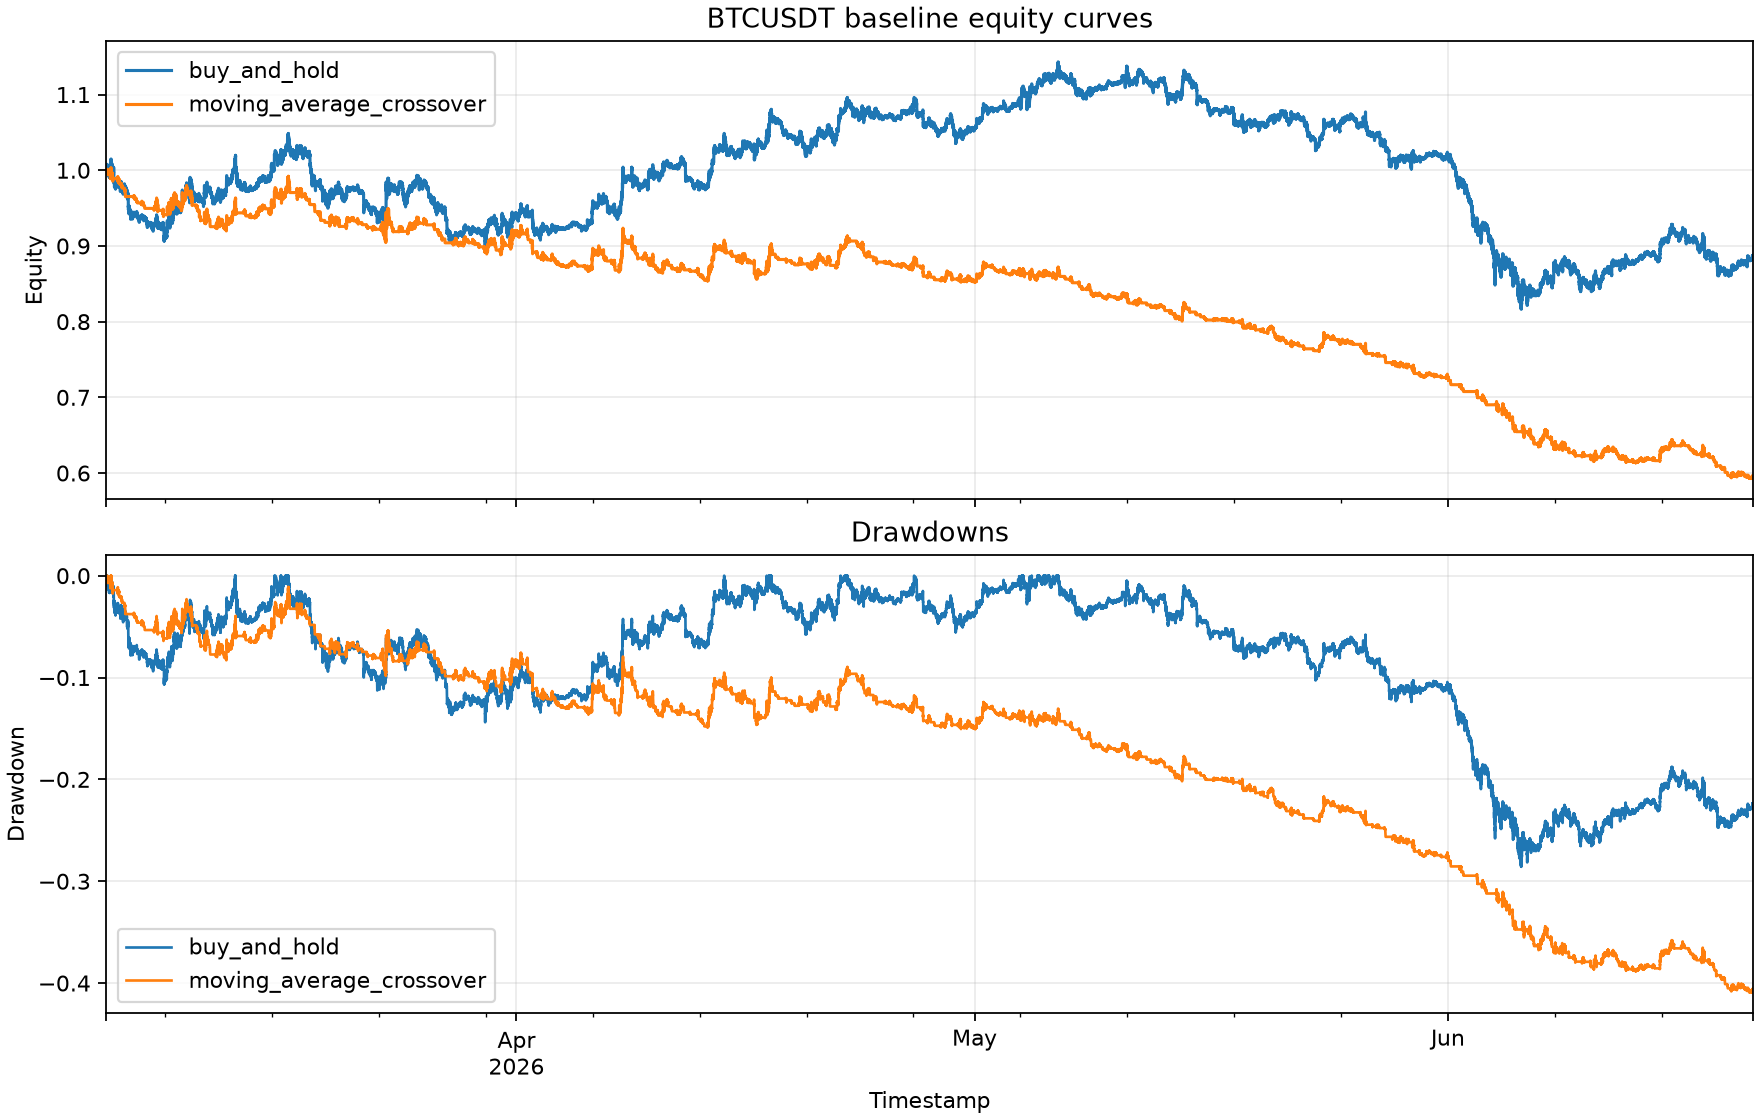

In [4]:
show_figure("reports/figures/baseline_equity_curve.png")

## 2.2 Econometric, ML, and AI-Agent Strategy for One Asset

The enhanced BTCUSDT experiment compares rolling econometric forecasts, a RandomForest direction classifier, and a deterministic agent layer that combines baseline, econometric, and ML votes with volatility/drawdown controls.

In [5]:
model_metrics = load_json("reports/metrics/single_asset_model_comparison.json")
comparison_frame(model_metrics)[["strategy", "total_return", "annualized_volatility", "sharpe_ratio", "max_drawdown", "turnover"]]

,strategy,total_return,annualized_volatility,sharpe_ratio,max_drawdown,turnover
0,buy_and_hold,-0.1126,0.4310,-0.7224,-0.2859,1.0
1,moving_average_crossover,-0.4040,0.2942,-5.8061,-0.4091,657.0
2,econometric_rolling,-0.4125,0.2452,-7.2193,-0.4207,773.0
3,random_forest,-0.0613,0.0437,-4.8854,-0.0684,140.0
4,agent_enhanced,-0.1321,0.1078,-4.3925,-0.1399,194.0


In [6]:
model_metrics["training_summary"]

{'agent_volatility_limit': 0.000931672194480981,
 'available_training_rows': 362015,
 'econometric_confirmation_ratio': 0.8,
 'econometric_confirmation_window': 30,
 'econometric_threshold': 8.331638479217959e-06,
 'feature_importance': {'ma_distance_60_360': 0.0436913665117225,
  'momentum_15': 0.08872682114027701,
  'momentum_60': 0.06872208710858158,
  'return_1': 0.1661169656570837,
  'return_lag_1': 0.06649716706840238,
  'return_lag_2': 0.03966407449033159,
  'return_lag_4': 0.03823201600688396,
  'return_lag_5': 0.039351043991220656,
  'rolling_vol_240': 0.16862859220606563,
  'rolling_vol_60': 0.1659332446350787},
 'majority_class_rate_train': 0.5187333333333333,
 'random_chance_reference': 0.5,
 'random_forest_test_direction_accuracy': 0.513802051473571,
 'random_forest_test_roc_auc': 0.5267166496626905,
 'random_forest_train_accuracy': 0.5411583333333333,
 'target_positive_rate_test': 0.48954624186268136,
 'target_positive_rate_train': 0.4812666666666667,
 'test_signal_rows':

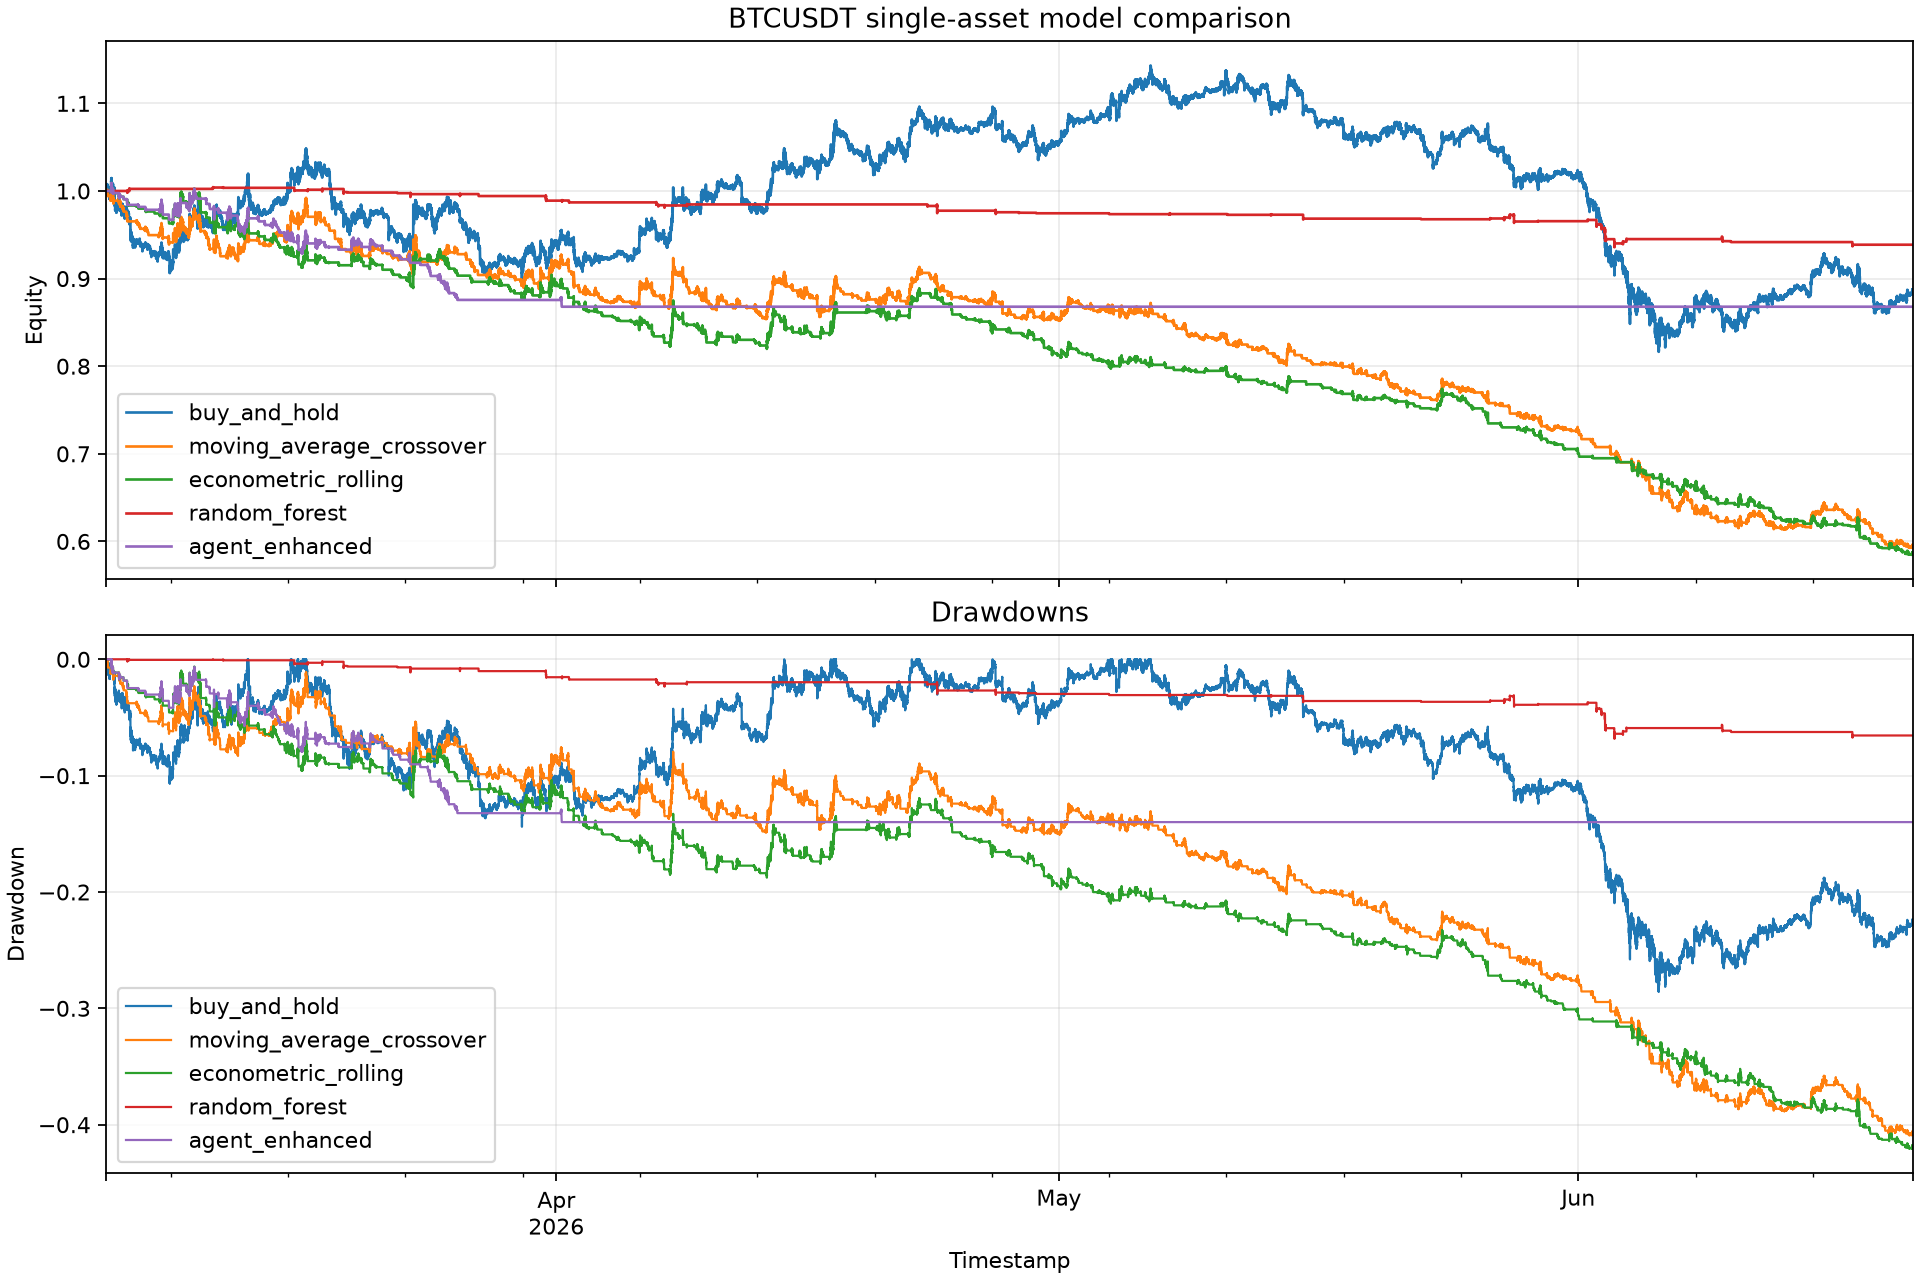

In [7]:
show_figure("reports/figures/single_asset_model_comparison.png")

## 2.3 Static Portfolio Management for 5-7 Coins

The static portfolio expands from BTCUSDT to six liquid USDT pairs: BTC, ETH, BNB, SOL, XRP, and ADA. Weights are fitted on the training period only and evaluated on the out-of-sample test period.

In [8]:
static_metrics = load_json("reports/metrics/static_portfolio_metrics.json")
comparison_frame(static_metrics)[["strategy", "total_return", "annualized_volatility", "sharpe_ratio", "max_drawdown", "effective_assets", "max_weight"]]

,strategy,total_return,annualized_volatility,sharpe_ratio,max_drawdown,effective_assets,max_weight
0,equal_weight,-0.1941,0.4884,-1.2514,-0.3285,6.0000,0.1667
1,inverse_volatility,-0.1728,0.4697,-1.1319,-0.3108,5.5598,0.2562
2,max_sharpe_constrained,-0.1497,0.4593,-0.9649,-0.2931,2.9851,0.3500


In [9]:
{
    "selected_method": static_metrics["selected_method"],
    "selection_criterion": static_metrics["selection_criterion"],
    "weights": static_metrics["weights"][static_metrics["selected_method"]],
}

{'selected_method': 'max_sharpe_constrained',
 'selection_criterion': 'highest out-of-sample sharpe_ratio',
 'weights': {'ADAUSDT': 7.450910185859226e-17,
  'BNBUSDT': 0.34999999999999976,
  'BTCUSDT': 0.0,
  'ETHUSDT': 0.3499999999999995,
  'SOLUSDT': 2.5673907444456745e-16,
  'XRPUSDT': 0.30000000000000043}}

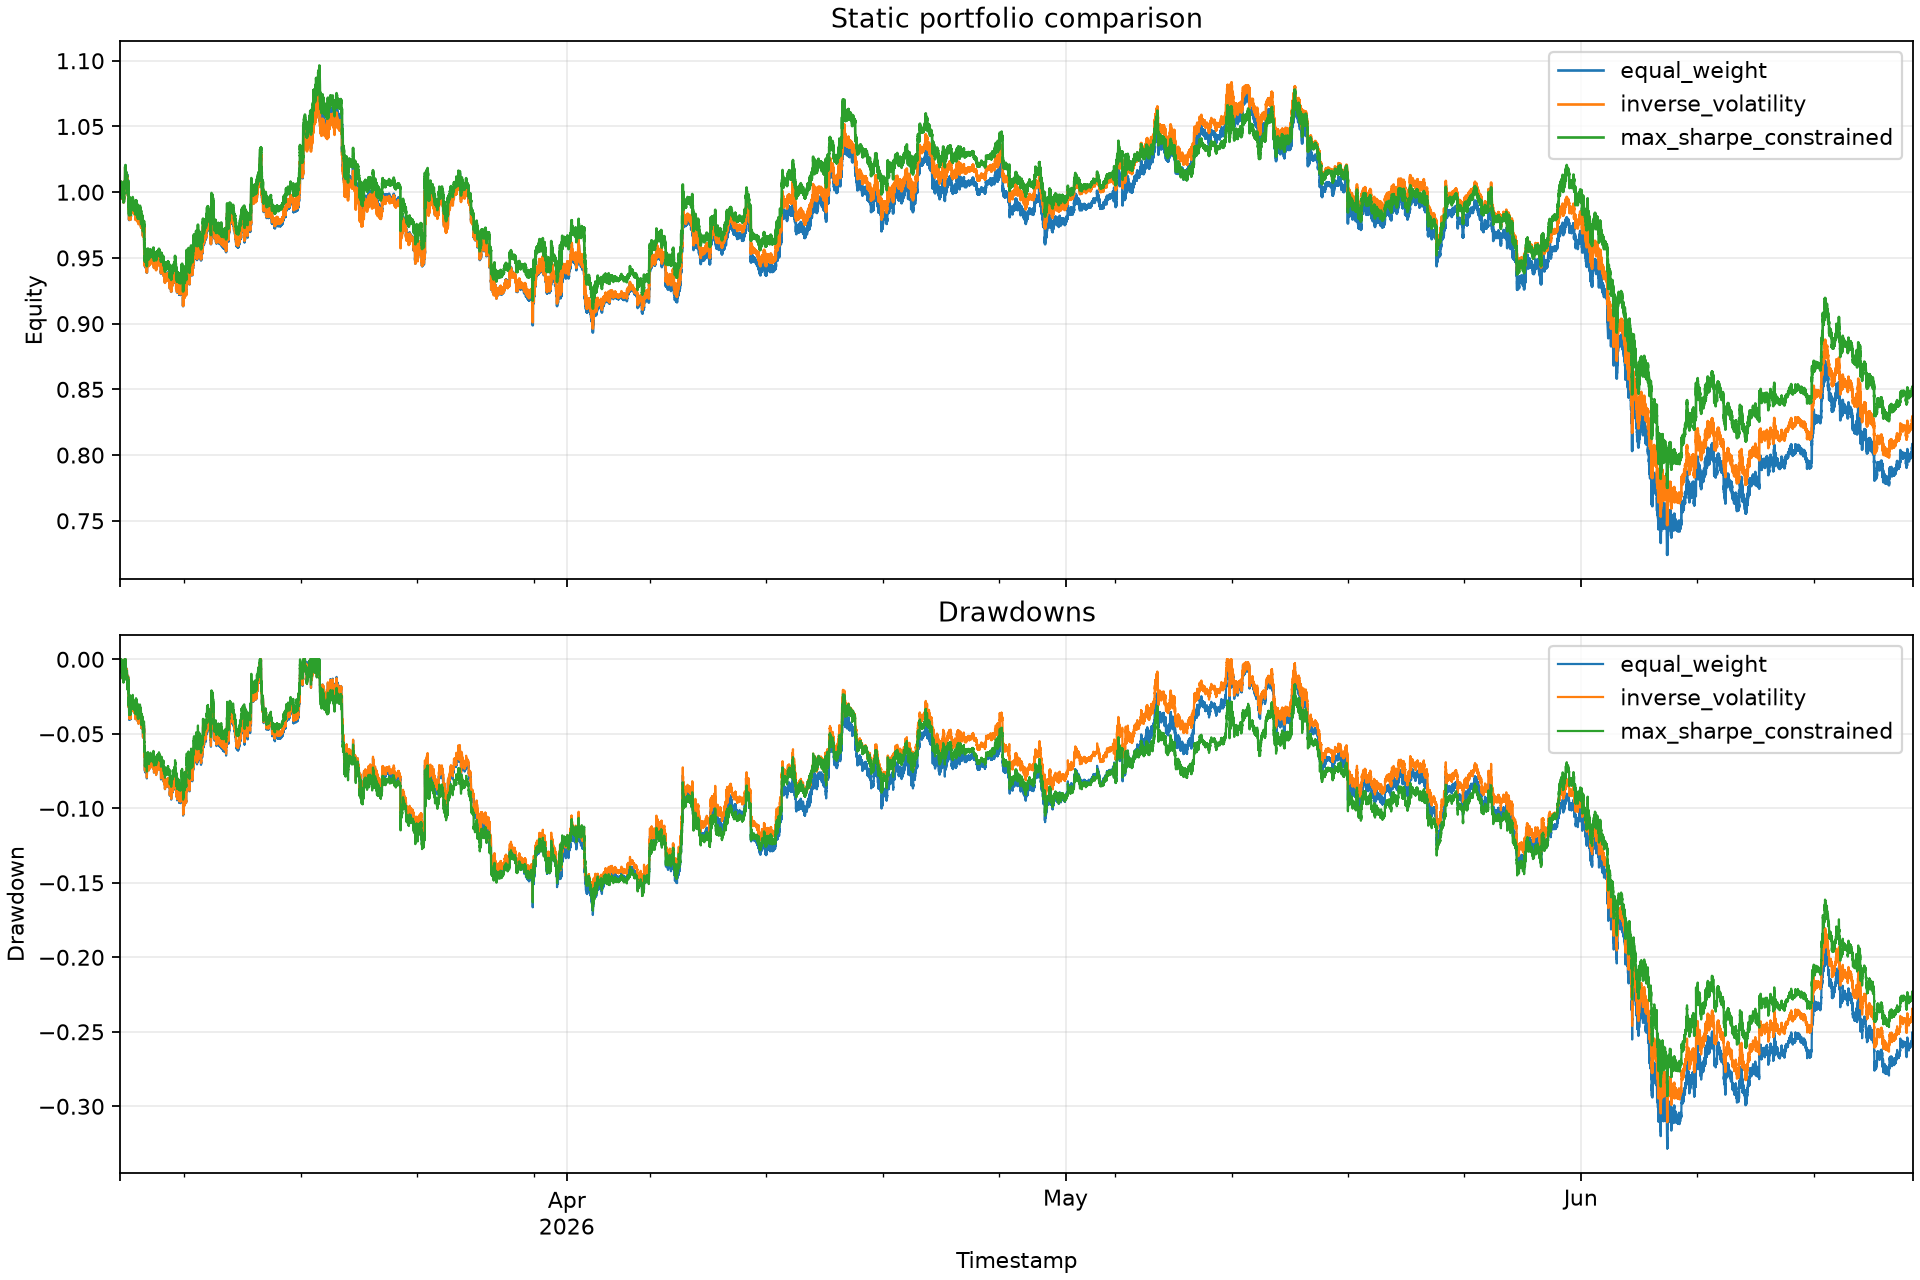

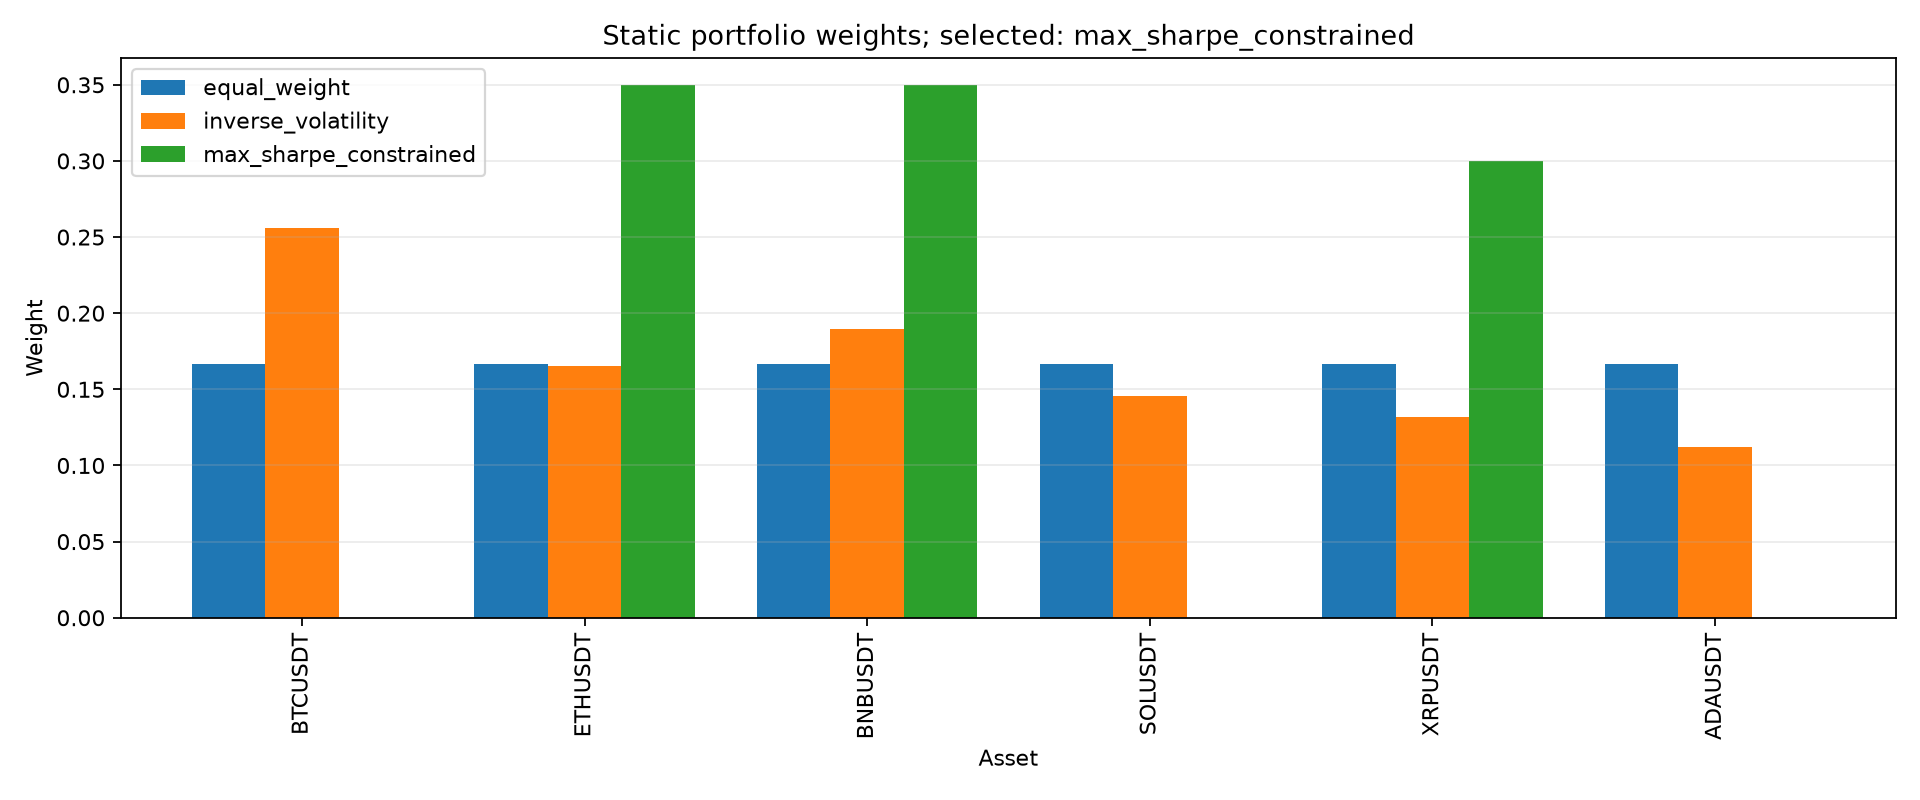

In [10]:
show_figure("reports/figures/static_portfolio_equity_curve.png")
show_figure("reports/figures/static_portfolio_weights.png")

## 2.4 Dynamic Portfolio Rebalancing

The dynamic experiment compares the selected static max-Sharpe portfolio with weekly inverse-volatility rebalancing and threshold rebalancing when passive holding drift exceeds 2 percentage points.

In [11]:
rebalancing_metrics = load_json("reports/metrics/rebalancing_metrics.json")
comparison_frame(rebalancing_metrics)[["strategy", "total_return", "annualized_volatility", "sharpe_ratio", "max_drawdown", "turnover", "rebalance_events"]]

,strategy,total_return,annualized_volatility,sharpe_ratio,max_drawdown,turnover,rebalance_events
0,static_max_sharpe_reference,-0.1497,0.4593,-0.9649,-0.2931,1.000,0.0
1,weekly_inverse_volatility,-0.1801,0.4725,-1.1857,-0.3120,1.323,16.0
2,threshold_inverse_volatility,-0.1755,0.4736,-1.1427,-0.3102,1.221,5.0


In [12]:
{
    "selected_strategy": rebalancing_metrics["selected_strategy"],
    "event_summary": rebalancing_metrics["event_summary"],
}

{'selected_strategy': 'static_max_sharpe_reference',
 'event_summary': {'static_max_sharpe_reference': {'average_event_turnover': 0.0,
   'backtest_turnover': 1.0,
   'event_count': 0.0,
   'event_turnover': 0.0},
  'threshold_inverse_volatility': {'average_event_turnover': 0.2682485282672375,
   'backtest_turnover': 1.2210009129247108,
   'event_count': 5.0,
   'event_turnover': 1.3412426413361875},
  'weekly_inverse_volatility': {'average_event_turnover': 0.08268954718167515,
   'backtest_turnover': 1.323032754906802,
   'event_count': 16.0,
   'event_turnover': 1.3230327549068024}}}

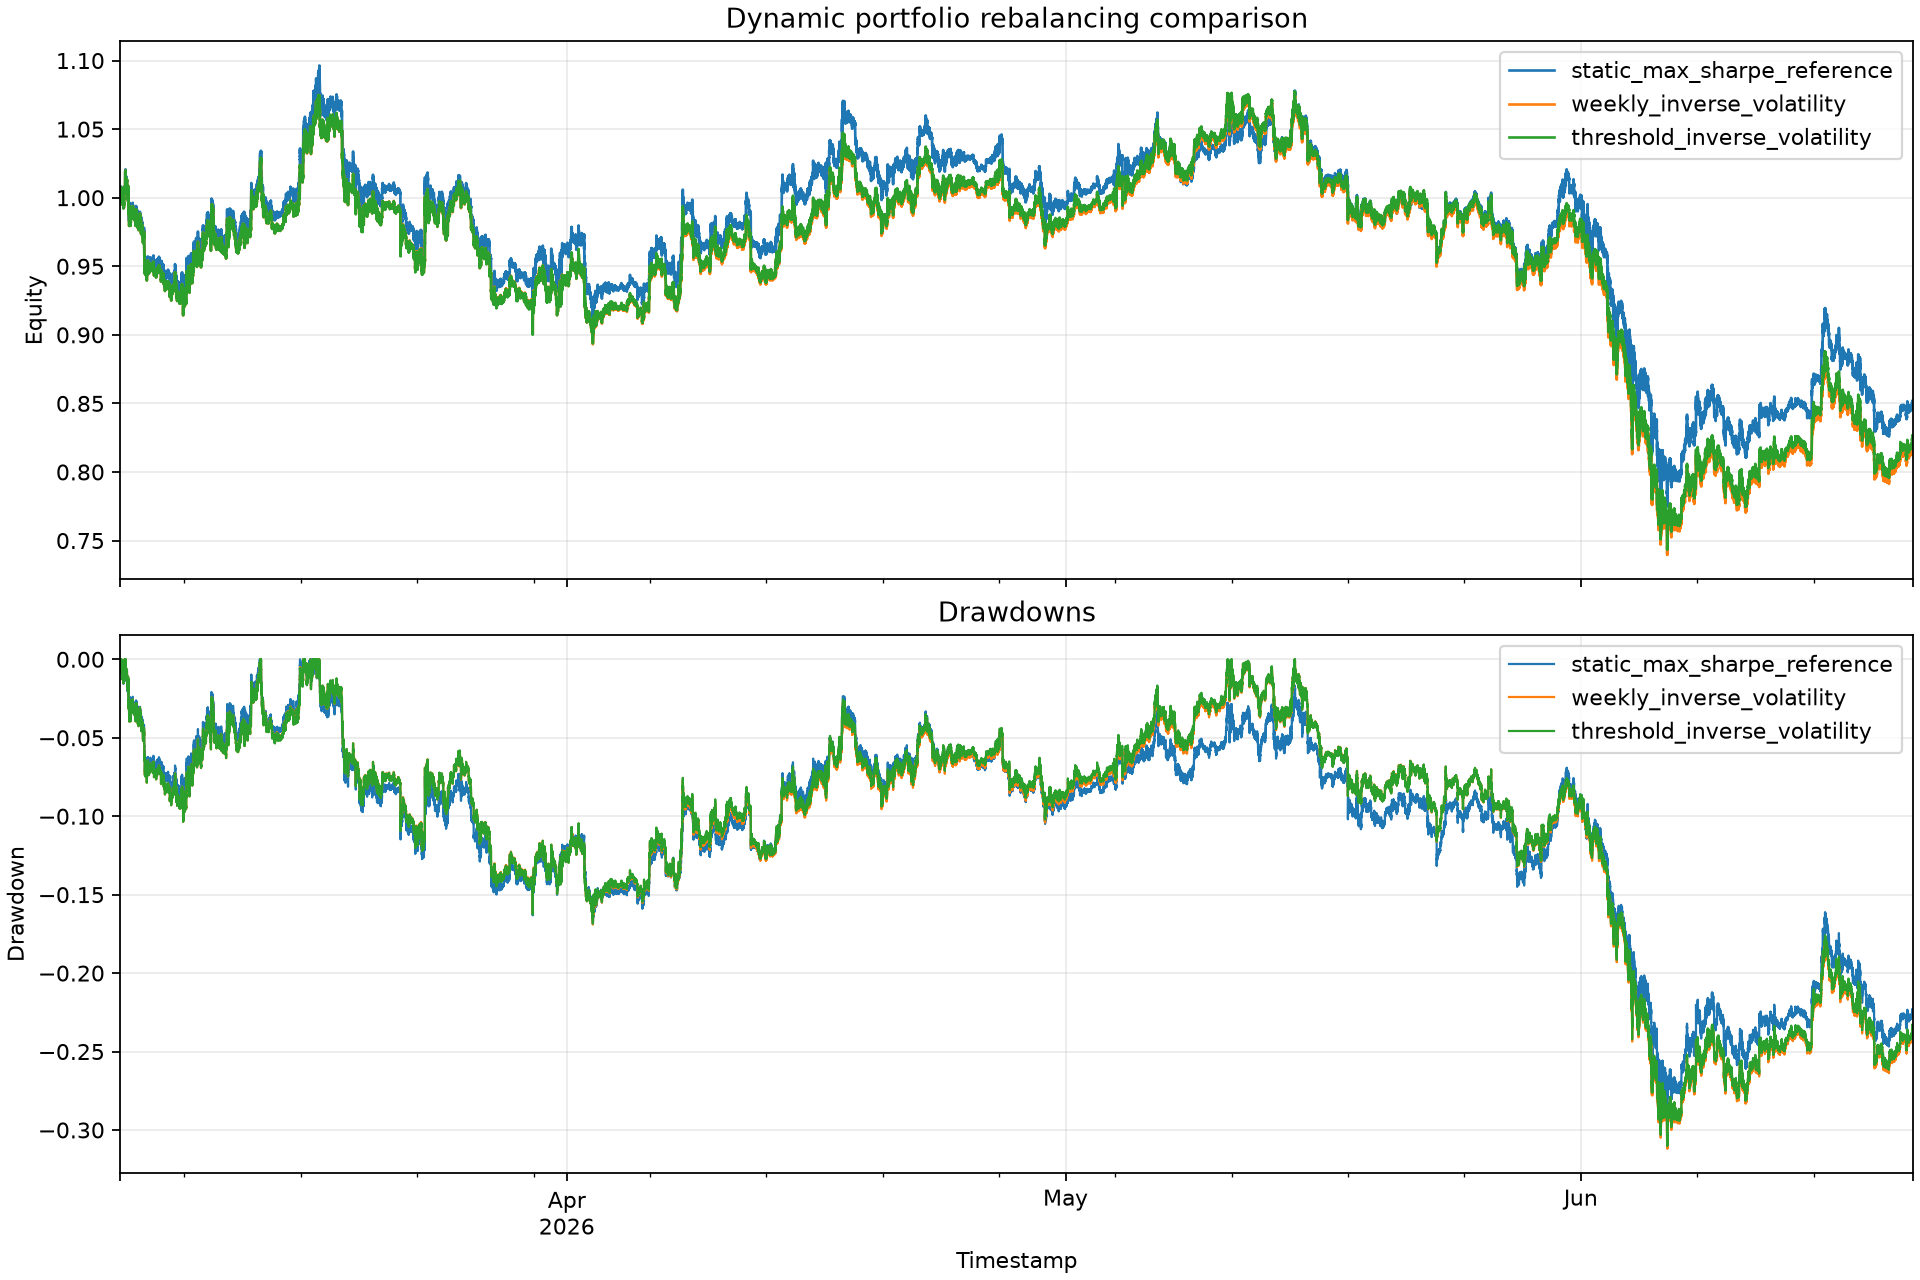

In [13]:
show_figure("reports/figures/rebalancing_comparison.png")

## 2.5 Large-Universe Portfolio with Dynamic Rebalancing

The large-universe experiment uses the full 120-pair Binance spot snapshot and compares a broad equal-weight reference with two sparse weekly dynamic allocators. The sparse allocators rank assets from trailing momentum and volatility, select the top 20 active symbols, cap each asset at 8%, and scale gross exposure down when trailing portfolio volatility is above target.

In [14]:
large_universe_metrics = load_json("reports/metrics/large_universe_metrics.json")
comparison_frame(large_universe_metrics)[["strategy", "total_return", "annualized_volatility", "sharpe_ratio", "max_drawdown", "turnover", "rebalance_events", "average_active_assets"]]

,strategy,total_return,annualized_volatility,sharpe_ratio,max_drawdown,turnover,rebalance_events,average_active_assets
0,large_universe_equal_weight,0.1439,0.4868,1.1781,-0.2932,1.0000,0.0,0.0
1,top_momentum_weekly,0.0149,0.6572,0.4050,-0.2980,24.2638,16.0,20.0
2,risk_adjusted_momentum_weekly,-0.0378,0.6417,0.1176,-0.2783,24.6452,16.0,20.0


In [15]:
selected_assets = pd.read_csv(ROOT / "reports" / "metrics" / "large_universe_selected_assets.csv")
{
    "universe_size": large_universe_metrics["universe_size"],
    "selected_strategy": large_universe_metrics["selected_strategy"],
    "data_files": {
            "processed_dir": "data/external/binance_spot_1m_120_12mo/processed",
            "prices_1m.parquet": {
                "size_bytes": large_universe_metrics["data_files"]["prices_1m.parquet"]["size_bytes"],
                "sha256": large_universe_metrics["data_files"]["prices_1m.parquet"]["sha256"],
            },
            "returns_1m.parquet": {
                "size_bytes": large_universe_metrics["data_files"]["returns_1m.parquet"]["size_bytes"],
                "sha256": large_universe_metrics["data_files"]["returns_1m.parquet"]["sha256"],
            },
        },
    "selected_assets_preview": selected_assets.head(10).to_dict(orient="records"),
}

{'universe_size': 120,
 'selected_strategy': 'large_universe_equal_weight',
 'data_files': {'processed_dir': 'data/external/binance_spot_1m_120_12mo/processed',
  'prices_1m.parquet': {'size_bytes': 95258376,
   'sha256': '027a8a0ba6841e04e39513f8262a5d451bcb27369bb07a308e6059d617ef9dff'},
  'returns_1m.parquet': {'size_bytes': 193142203,
   'sha256': '2c4b8ed154f959fe7cb598524b214fcb423acab61ef3ae3169a4c717af6fe491'}},
 'selected_assets_preview': [{'event_id': 1,
   'timestamp': '2026-03-05T03:37:00+00:00',
   'strategy': 'top_momentum_weekly',
   'symbol': 'PHAUSDT',
   'selection_rank': 1,
   'score': 1.0206611570247714,
   'momentum': 1.0206611570247714,
   'volatility': 0.0026600858203933,
   'coverage': 1.0,
   'weight': 0.0597528694803108,
   'gross_exposure': 0.7469108685038857,
   'event_turnover': 0.7469108685038857},
  {'event_id': 1,
   'timestamp': '2026-03-05T03:37:00+00:00',
   'strategy': 'top_momentum_weekly',
   'symbol': 'SAHARAUSDT',
   'selection_rank': 2,
   'scor

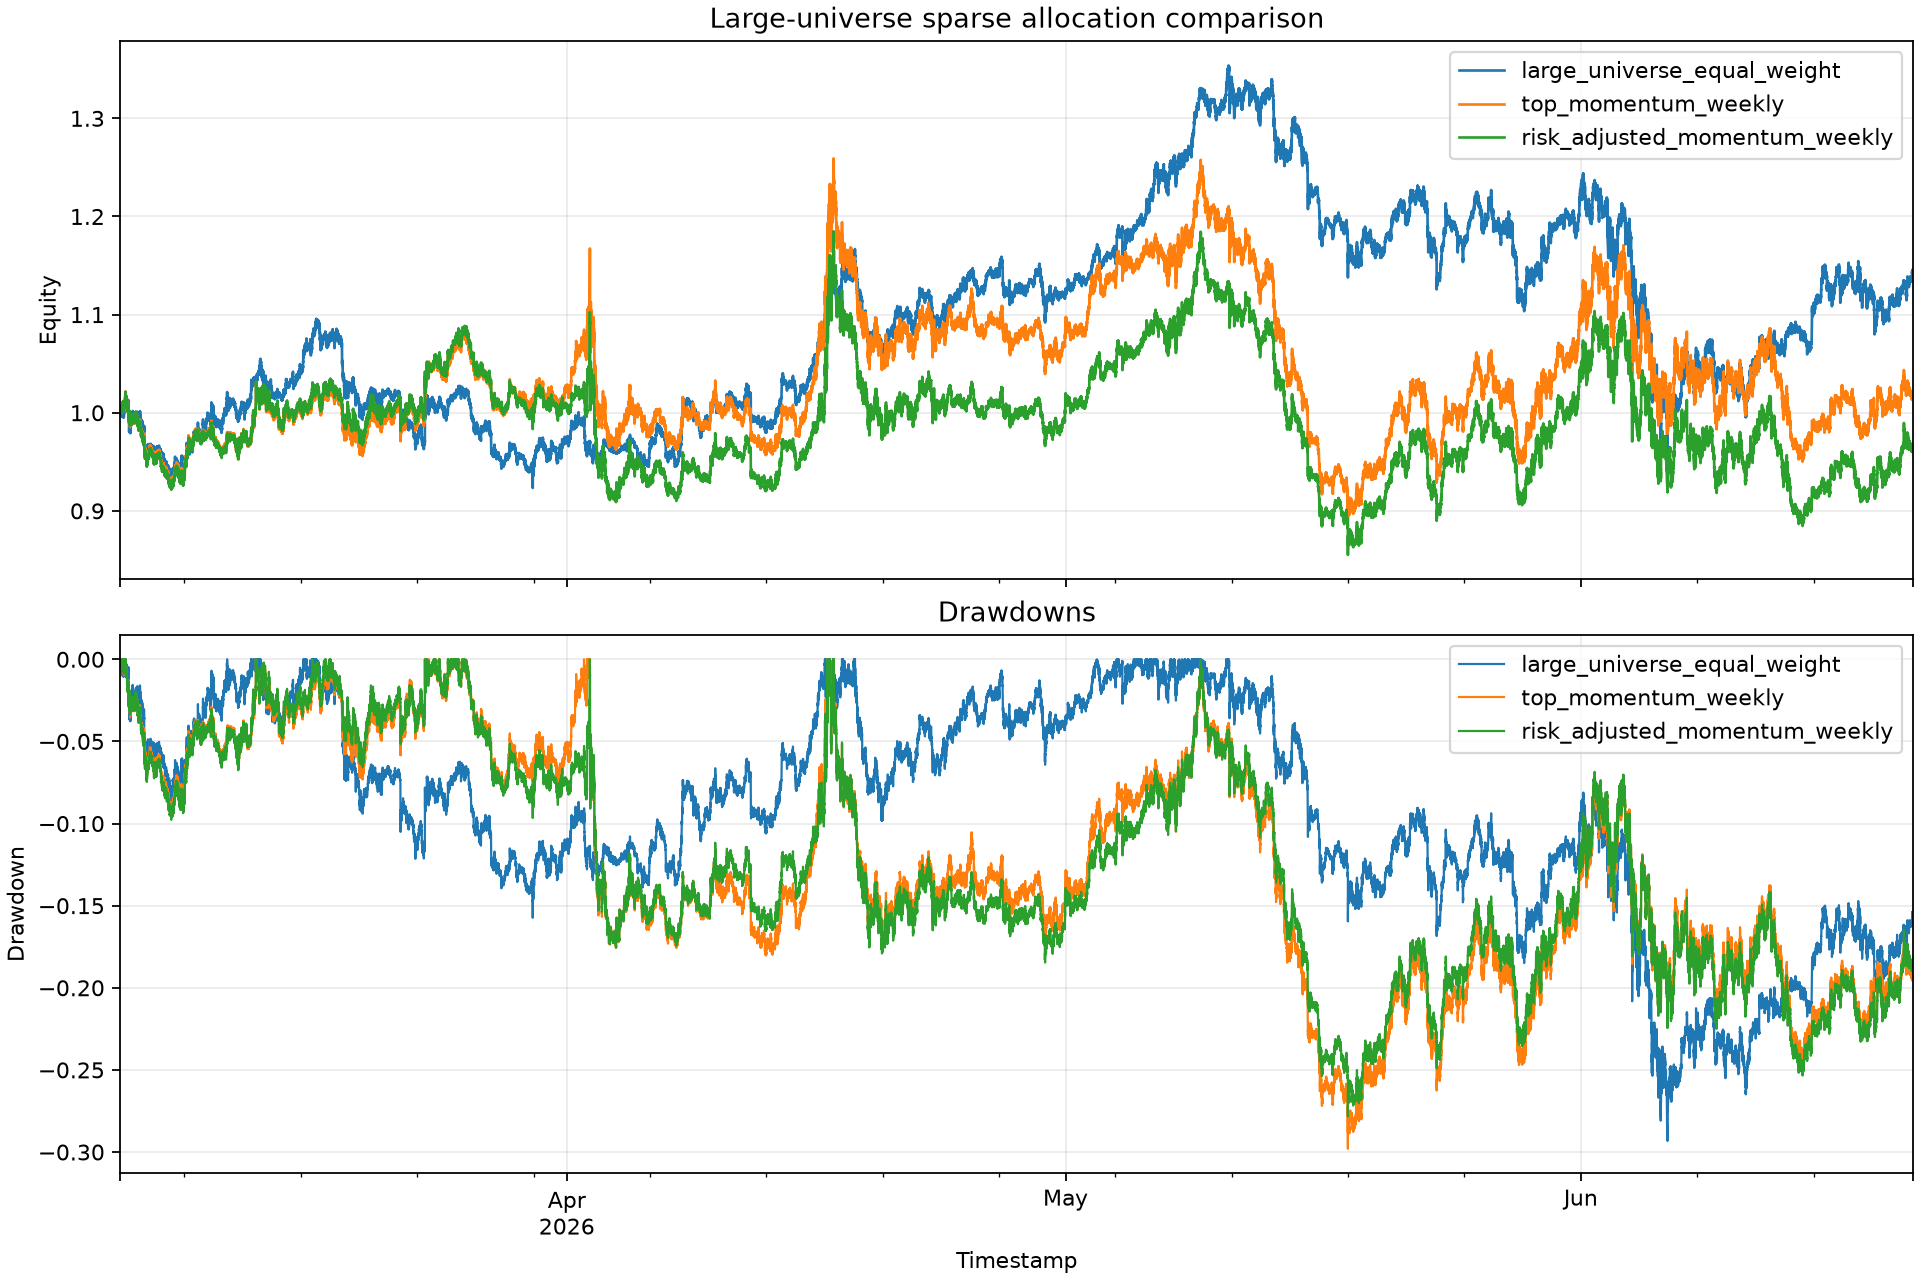

In [16]:
show_figure("reports/figures/large_universe_equity_curve.png")

## 3. Summary, Limitations, and Next Steps

Key results:

- The BTCUSDT RandomForest policy reduced drawdown versus buy-and-hold during the single-asset test period, but the single-asset strategies remained challenged by costs and noisy 1-minute labels.
- The six-asset static max-Sharpe portfolio was the best small-universe strategy by out-of-sample Sharpe.
- Simple dynamic inverse-volatility rebalancing did not improve the six-asset portfolio after turnover.
- In the 120-pair experiment, broad equal weight outperformed the sparse weekly momentum strategies on the selected out-of-sample window.

Limitations:

- All trading is simulated; there is no live execution.
- Fills use minute-close prices and simplified transaction costs.
- The full data bundle is ignored by git and will be published separately in the final data-publication task.
- The ML and momentum signals are deliberately simple MVP signals, not production alpha research.

Production next steps:

- Add exchange-specific slippage, fee tiers, and order-size constraints.
- Add monitoring for stale data, failed orders, exposure drift, realized costs, drawdown, and active-set instability.
- Add fail-safes: stale-data block, maximum rebalance turnover, drawdown stop, exchange outage mode, and manual kill switch.
- Re-test on multiple time periods before treating any strategy as deployable.